For CVAE

In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from matplotlib.font_manager import FontProperties
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import LabelEncoder

In [2]:
base_path = r"..\..\Data\2.Data_transposed\\"

In [3]:
# Data loading
print("started...")
start_time = datetime.now()
num_samples = 1000000

data_tomato_healthy = pd.read_excel(base_path + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_tomato_unhealthy = pd.read_excel(base_path + "tomato_Unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_potato = pd.read_excel(base_path + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_chilli = pd.read_excel(base_path + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_capsicum = pd.read_excel(base_path + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_mulberry = pd.read_excel(base_path + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

started...
Data loading time is:> 0:00:40.074175


In [4]:
# Data shapes
print("Tomato healthy:", data_tomato_healthy.shape)
print("Tomato unhealthy:", data_tomato_unhealthy.shape)
print("potato:", data_potato.shape)
print("Chilli:", data_chilli.shape)
print("Capsicum:", data_capsicum.shape)
print("Mulberry:", data_mulberry.shape)

# Data Concatenating
df = pd.concat([data_tomato_healthy, data_tomato_unhealthy, data_potato, data_chilli, data_capsicum, data_mulberry], axis = 0)
df_final=df.copy()
df_final

Tomato healthy: (2670, 944)
Tomato unhealthy: (274, 944)
potato: (770, 944)
Chilli: (125, 944)
Capsicum: (75, 944)
Mulberry: (150, 944)


,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.008590,0.008290,0.006470,0.005260,0.010600,0.013100,0.012600,0.011900,0.014300,...,0.034100,0.033800,0.033300,0.032700,0.032378,0.032500,0.032000,0.031000,0.030800,0.030600
1,tomato_healthy,0.016800,0.019900,0.021000,0.019600,0.021500,0.021200,0.019200,0.017600,0.017400,...,0.041700,0.041000,0.040400,0.038667,0.037700,0.037700,0.037500,0.036800,0.036000,0.035800
2,tomato_healthy,0.017200,0.017200,0.015400,0.013800,0.015400,0.014800,0.013900,0.015000,0.015636,...,0.029936,0.030500,0.030000,0.029100,0.028700,0.028400,0.027800,0.027900,0.027000,0.022900
3,tomato_healthy,0.017800,0.019100,0.023800,0.025300,0.022220,0.024600,0.027700,0.026100,0.029300,...,0.283379,0.282930,0.281796,0.281533,0.279989,0.276878,0.275332,0.274354,0.272459,0.269984
4,tomato_healthy,0.018700,0.018600,0.019100,0.020400,0.020800,0.020100,0.020600,0.022723,0.018100,...,0.042100,0.041500,0.040800,0.040100,0.039700,0.039800,0.039300,0.038595,0.038288,0.037600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,mulberry,0.573306,0.573000,0.572998,0.569235,0.563801,0.560817,0.559438,0.557566,0.554873,...,0.948777,0.945351,0.942158,0.939933,0.937892,0.934026,0.932825,0.935597,0.935638,0.935472
69,mulberry,0.092460,0.093582,0.090590,0.085812,0.091711,0.091912,0.091382,0.096271,0.092623,...,0.508448,0.506358,0.504675,0.505341,0.503036,0.498737,0.496101,0.491324,0.489177,0.491635
44,mulberry,0.142020,0.137261,0.139998,0.148820,0.137722,0.132087,0.134780,0.140108,0.135779,...,0.627624,0.626296,0.624100,0.624446,0.622156,0.615777,0.613188,0.612755,0.610758,0.608501
111,mulberry,0.015847,0.016089,0.020271,0.024543,0.020046,0.019280,0.021383,0.022376,0.021970,...,0.415157,0.412162,0.410535,0.410909,0.409635,0.406608,0.406296,0.408461,0.407565,0.405667


In [5]:
# Loading CTGAN Syntetic data

base_path = r"..\..\Data\7.CNN_CVAE\best(75 Real+BSMOTE)\\"

In [6]:
# Data loading
print("started...")
start_time = datetime.now()
num_samples = 1000000

data_tomato_healthy = pd.read_excel(base_path + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_tomato_unhealthy = pd.read_excel(base_path + "tomato_Unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_potato = pd.read_excel(base_path + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_chilli = pd.read_excel(base_path + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_capsicum = pd.read_excel(base_path + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_mulberry = pd.read_excel(base_path + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

started...
Data loading time is:> 0:01:57.745330


In [12]:
# Data shapes
print("Tomato healthy:", data_tomato_healthy.shape)
print("Tomato unhealthy:", data_tomato_unhealthy.shape)
print("potato:", data_potato.shape)
print("Chilli:", data_chilli.shape)
print("Capsicum:", data_capsicum.shape)
print("Mulberry:", data_mulberry.shape)

# Data Concatenating
df = pd.concat([data_tomato_healthy, data_tomato_unhealthy, data_potato, data_chilli, data_capsicum, data_mulberry], axis = 0)
resampled_df = df.copy()
resampled_df

Tomato healthy: (2000, 944)
Tomato unhealthy: (2000, 944)
potato: (2000, 944)
Chilli: (2000, 944)
Capsicum: (2000, 944)
Mulberry: (2000, 944)


,400,401,402,403,404,405,406,407,408,409,...,1334,1335,1336,1337,1338,1339,1340,1341,1342,label
0,0.046978,0.045881,0.045069,0.044841,0.044389,0.044640,0.045803,0.046619,0.046570,0.047017,...,0.467746,0.462663,0.459354,0.458862,0.457716,0.458307,0.455261,0.448523,0.446110,4
1,0.097758,0.099221,0.100812,0.100913,0.100067,0.100702,0.101694,0.101653,0.100559,0.101502,...,0.584243,0.583126,0.581107,0.580880,0.578755,0.578560,0.579134,0.577528,0.576237,4
2,0.191330,0.196658,0.202296,0.201688,0.203610,0.200199,0.197171,0.193806,0.193900,0.189637,...,0.396992,0.396595,0.397659,0.396217,0.396145,0.395811,0.391985,0.390165,0.388951,4
3,0.106824,0.108040,0.108713,0.108824,0.108967,0.109915,0.111124,0.110815,0.111276,0.112111,...,0.534744,0.533410,0.532419,0.529573,0.526105,0.526052,0.523599,0.521170,0.521663,4
4,0.076852,0.078742,0.079612,0.079775,0.080099,0.081894,0.083736,0.084259,0.083975,0.084170,...,0.535107,0.532157,0.525963,0.526008,0.526194,0.524719,0.521827,0.520366,0.515912,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.040187,0.040768,0.042232,0.041737,0.038009,0.038126,0.039168,0.040969,0.039510,0.040600,...,0.406626,0.406676,0.405540,0.407660,0.406598,0.403469,0.398929,0.396533,0.395465,2
335,0.218137,0.217984,0.217497,0.216059,0.214894,0.214453,0.214333,0.213902,0.213029,0.212199,...,0.646315,0.644060,0.641921,0.639874,0.638147,0.636621,0.634897,0.633606,0.633287,2
510,0.218126,0.217983,0.217497,0.216059,0.214894,0.214453,0.214333,0.213902,0.213029,0.212199,...,0.602869,0.596225,0.595593,0.596343,0.596819,0.595233,0.596889,0.590370,0.590111,2
1346,0.131260,0.128711,0.127757,0.130006,0.126038,0.126259,0.127922,0.127580,0.124979,0.125108,...,0.629632,0.626669,0.625971,0.620484,0.618434,0.615144,0.616217,0.612831,0.610997,2


In [13]:
# Replace inter label with crop name label

# Mapping dictionary
label_map = {
    0: "capsicum",
    1: "chilli",
    2: "mulberry",
    3: "potato",
    4: "tomato_healthy",
    5: "tomato_unhealthy"
}

# Replace values
resampled_df['label'] = resampled_df['label'].map(label_map)
resampled_df

,400,401,402,403,404,405,406,407,408,409,...,1334,1335,1336,1337,1338,1339,1340,1341,1342,label
0,0.046978,0.045881,0.045069,0.044841,0.044389,0.044640,0.045803,0.046619,0.046570,0.047017,...,0.467746,0.462663,0.459354,0.458862,0.457716,0.458307,0.455261,0.448523,0.446110,tomato_healthy
1,0.097758,0.099221,0.100812,0.100913,0.100067,0.100702,0.101694,0.101653,0.100559,0.101502,...,0.584243,0.583126,0.581107,0.580880,0.578755,0.578560,0.579134,0.577528,0.576237,tomato_healthy
2,0.191330,0.196658,0.202296,0.201688,0.203610,0.200199,0.197171,0.193806,0.193900,0.189637,...,0.396992,0.396595,0.397659,0.396217,0.396145,0.395811,0.391985,0.390165,0.388951,tomato_healthy
3,0.106824,0.108040,0.108713,0.108824,0.108967,0.109915,0.111124,0.110815,0.111276,0.112111,...,0.534744,0.533410,0.532419,0.529573,0.526105,0.526052,0.523599,0.521170,0.521663,tomato_healthy
4,0.076852,0.078742,0.079612,0.079775,0.080099,0.081894,0.083736,0.084259,0.083975,0.084170,...,0.535107,0.532157,0.525963,0.526008,0.526194,0.524719,0.521827,0.520366,0.515912,tomato_healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.040187,0.040768,0.042232,0.041737,0.038009,0.038126,0.039168,0.040969,0.039510,0.040600,...,0.406626,0.406676,0.405540,0.407660,0.406598,0.403469,0.398929,0.396533,0.395465,mulberry
335,0.218137,0.217984,0.217497,0.216059,0.214894,0.214453,0.214333,0.213902,0.213029,0.212199,...,0.646315,0.644060,0.641921,0.639874,0.638147,0.636621,0.634897,0.633606,0.633287,mulberry
510,0.218126,0.217983,0.217497,0.216059,0.214894,0.214453,0.214333,0.213902,0.213029,0.212199,...,0.602869,0.596225,0.595593,0.596343,0.596819,0.595233,0.596889,0.590370,0.590111,mulberry
1346,0.131260,0.128711,0.127757,0.130006,0.126038,0.126259,0.127922,0.127580,0.124979,0.125108,...,0.629632,0.626669,0.625971,0.620484,0.618434,0.615144,0.616217,0.612831,0.610997,mulberry


In [14]:
from common_fun import create_data, apply_pca, apply_TSNE, apply_UMAP, plot_3D, plot_3D_static

tomato_unhealthy real data shape: (274, 944)
tomato_unhealthy synthetic data shape: (2000, 944)


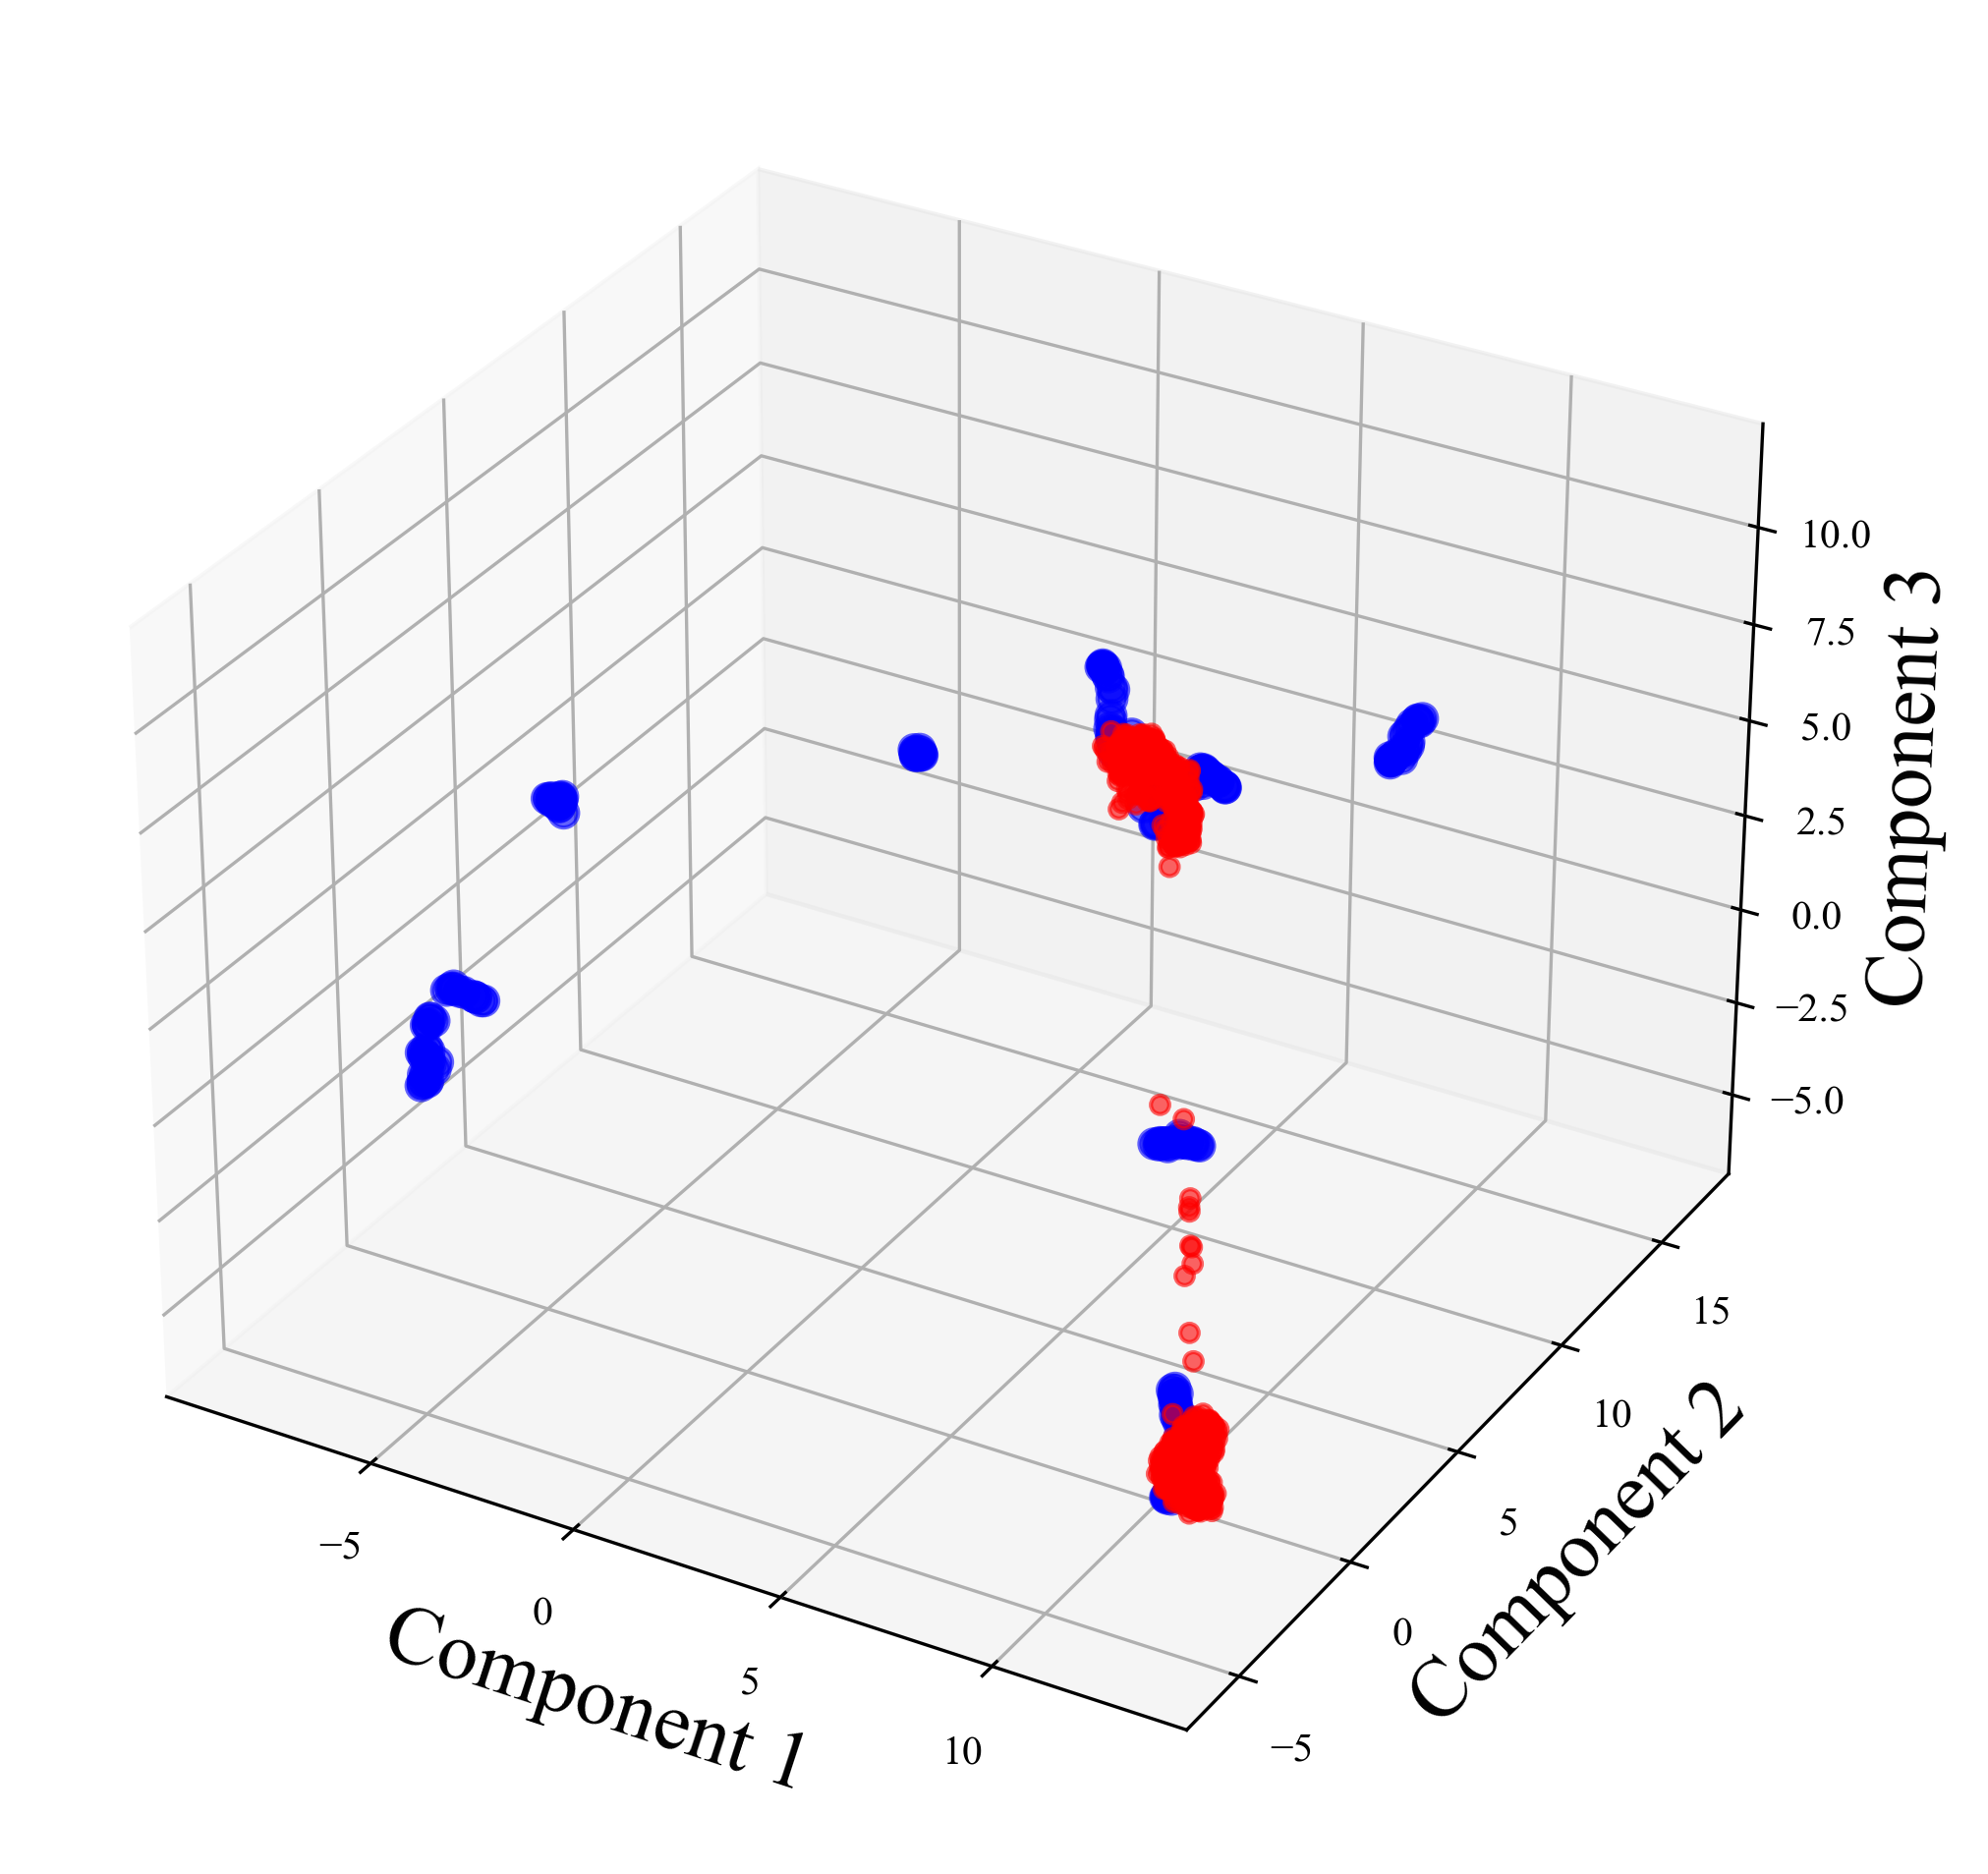

In [20]:
# tomato_healthy, tomato_unhealthy, chilli, potato, capsicum, mulberry
crop_name = "tomato_unhealthy" #capsicum, chilli, mulberry, potato, tomato_healthy, tomato_unhealthy
X_real_scaled, X_synthetic_scaled = create_data(crop_name, df_final, resampled_df)

# plot_df = apply_pca(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="PCA")

# plot_df = apply_TSNE(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="TSNE")

plot_df = apply_UMAP(X_real_scaled, X_synthetic_scaled)
plot_3D_static(crop_name, plot_df, ptype="UMAP")